In this Project, I analyzed the Titanic dataset to understand Survival prediction Patterns based on **Gender, Class and Age**.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
df=pd.read_csv('train.csv')

In [29]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Understanding dataset:
    - checking structure,columns and missing values

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [31]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Handling Missing values:
  -Filled missing values in Age using median
  -Filled missing values in Embarked using mode
  -Dropped Cabin column due to many missing values

In [32]:
df['Age']=df['Age'].fillna(df['Age'].mean())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df=df.drop(['Cabin'],axis=1)

In [33]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


**Basic Analysis**

In [34]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [35]:
df.groupby('Sex')['Survived'].value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

In [36]:
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [37]:
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [38]:
df.groupby('Pclass')['Survived'].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

In [39]:
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


Data Visualization

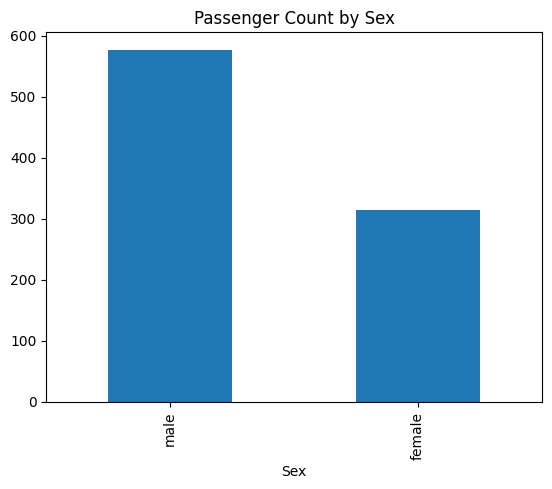

In [40]:
df['Sex'].value_counts().plot(kind='bar')
plt.title("Passenger Count by Sex")
plt.show()

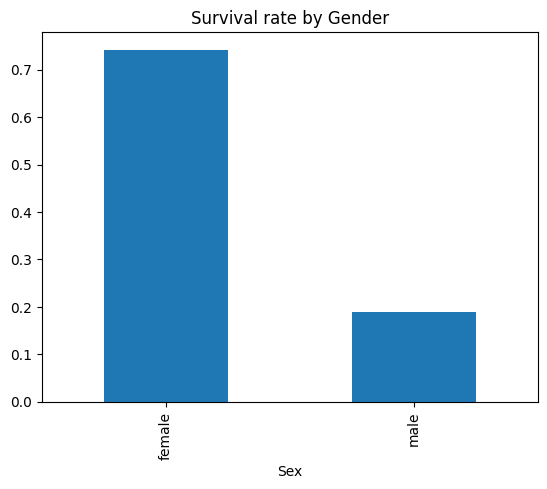

In [41]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title("Survival rate by Gender")
plt.show()

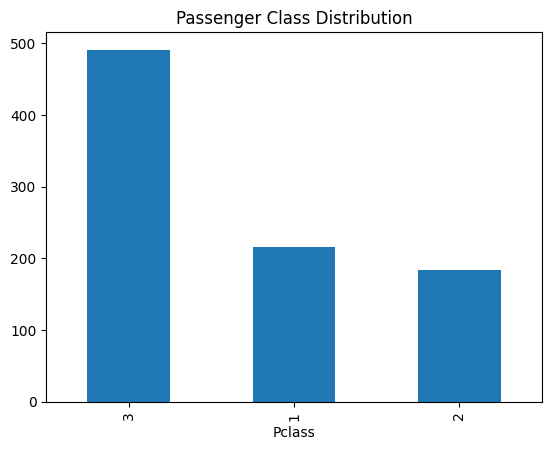

In [42]:
df['Pclass'].value_counts().plot(kind='bar')
plt.title("Passenger Class Distribution")
plt.show()

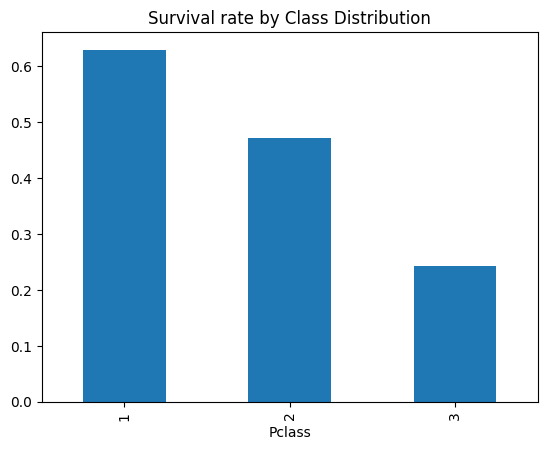

In [43]:
df.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.title("Survival rate by Class Distribution")
plt.show()

In [44]:
import seaborn as sns

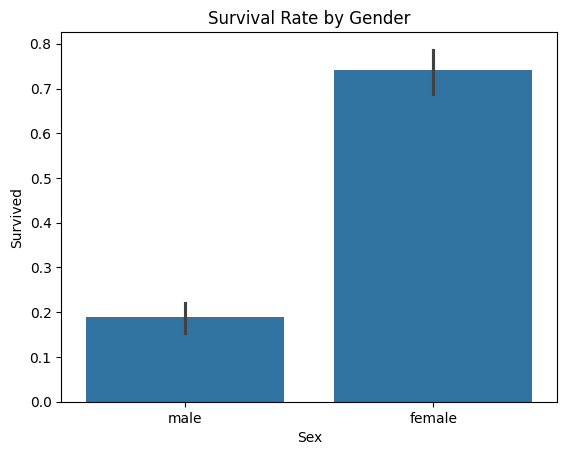

In [45]:
sns.barplot(x='Sex',y='Survived',data=df)
plt.title("Survival Rate by Gender")
plt.show()

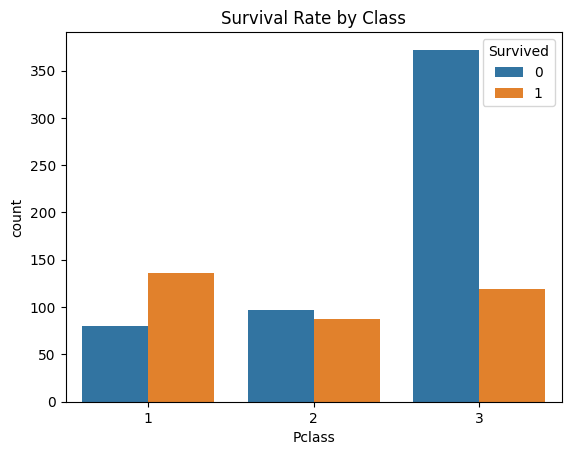

In [46]:
sns.countplot(x='Pclass',hue='Survived',data=df)
plt.title("Survival Rate by Class")
plt.show()


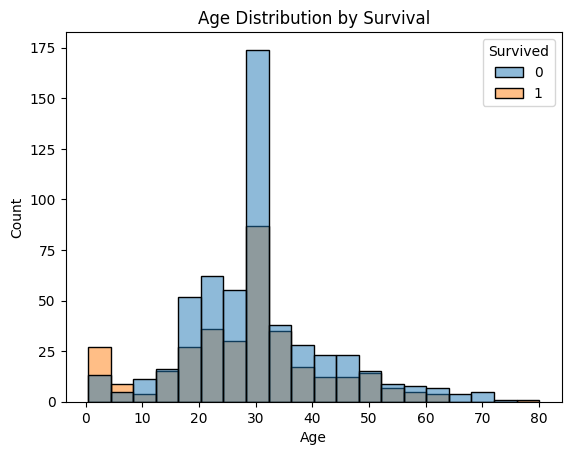

In [47]:
sns.histplot(x='Age',hue='Survived',bins=20,data=df)
plt.title("Age Distribution by Survival")
plt.show()


Key Insights:

- Females had a higher survival rate than males, even though the number of males was higher.
- First-class passengers were more likely to survive.
- Third-class had the highest number of passengers but the lowest survival rate.
- Younger passengers had slightly better survival chances compared to older passengers.